# Phase 3: Fine tuning the model for Chopin Waltz Completion

### 1- Install libraries

In [2]:
!pip install miditok transformers accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.0/159.0 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 111.1 MB/s eta 0:00:00


### 2- Mount drive and set path

In [8]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

# ── CONFIGURE THIS PATH ──
# Adjust if your folder name or location differs
BASE = Path("/content/drive/MyDrive/Chopin_waltz_completion")

TRAIN_DIR = BASE / "Data" / "chunked" / "train"
VALID_DIR = BASE / "Data" / "chunked" / "valid"
TOKENIZER_PATH = BASE / "Models" / "tokenizer.json"
OUTPUT_DIR = BASE / "Models" / "fine_tuned"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verify everything exists
train_files = list(TRAIN_DIR.glob("**/*.mid"))
valid_files = list(VALID_DIR.glob("**/*.mid"))
print(f"Training chunks: {len(train_files)}")
print(f"Validation chunks: {len(valid_files)}")
print(f"Tokenizer exists: {TOKENIZER_PATH.exists()}")

assert len(train_files) > 0, "No training files found — check your Drive path"
assert len(valid_files) > 0, "No validation files found — check your Drive path"
assert TOKENIZER_PATH.exists(), "Tokenizer not found — check your Drive path"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Training chunks: 643
Validation chunks: 6
Tokenizer exists: True


### 3- Load tokenizer

In [10]:
from miditok import REMI

tokenizer = REMI(params=str(TOKENIZER_PATH))
print(f"Tokenizer loaded — vocab size: {len(tokenizer)}")

PAD_ID = tokenizer["PAD_None"]
BOS_ID = tokenizer["BOS_None"]
EOS_ID = tokenizer["EOS_None"]
print(f"PAD={PAD_ID}, BOS={BOS_ID}, EOS={EOS_ID}")

Tokenizer loaded — vocab size: 20000
PAD=0, BOS=2, EOS=3


### 4- Load pre-trained models

In [11]:
import torch
from transformers import AutoModelForCausalLM

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

model = AutoModelForCausalLM.from_pretrained(
    "Natooz/Maestro-REMI-bpe20k",
    trust_remote_code=True,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded — {total_params:,} parameters")

Device: cuda
GPU: Tesla T4


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/812 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/196M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/230 [00:00<?, ?B/s]

Model loaded — 49,118,208 parameters


### 5- Create datasets

In [12]:
from miditok.pytorch_data import DatasetMIDI, DataCollator
from torch.utils.data import DataLoader

MAX_SEQ_LEN = 1024
BATCH_SIZE = 8

# Create datasets
train_dataset = DatasetMIDI(
    files_paths=train_files,
    tokenizer=tokenizer,
    max_seq_len=MAX_SEQ_LEN,
    bos_token_id=BOS_ID,
    eos_token_id=EOS_ID,
)

valid_dataset = DatasetMIDI(
    files_paths=valid_files,
    tokenizer=tokenizer,
    max_seq_len=MAX_SEQ_LEN,
    bos_token_id=BOS_ID,
    eos_token_id=EOS_ID,
)

# Create collator (handles padding)
collator = DataCollator(
    pad_token_id=PAD_ID,
    copy_inputs_as_labels=True,    # labels = shifted inputs (next-token prediction)
    shift_labels=True,
)

# Create data loaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(valid_dataset)}")
print(f"Steps per epoch: {len(train_loader)}")

# Quick check — inspect one batch
batch = next(iter(train_loader))
print(f"\nBatch keys: {batch.keys()}")
print(f"Input shape: {batch['input_ids'].shape}")
print(f"Labels shape: {batch['labels'].shape}")

Training samples: 643
Validation samples: 6
Steps per epoch: 81

Batch keys: dict_keys(['input_ids', 'labels', 'attention_mask'])
Input shape: torch.Size([8, 761])
Labels shape: torch.Size([8, 761])


### 6- Training setup

In [13]:
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup

# ── HYPERPARAMETERS ──
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 50
WARMUP_STEPS = 200
PATIENCE = 5

# Optimizer
optimizer = AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

# Learning rate scheduler (warmup + linear decay)
total_steps = len(train_loader) * NUM_EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=total_steps,
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {WARMUP_STEPS}")
print(f"Steps per epoch: {len(train_loader)}")

Total training steps: 4050
Warmup steps: 200
Steps per epoch: 81


### 7- TRAINING LOOP

In [14]:
import time
import json

def evaluate(model, loader, device):
    """Compute average loss on a dataset."""
    model.eval()
    total_loss = 0
    total_steps = 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            outputs = model(
                input_ids=input_ids,
                labels=labels,
                attention_mask=attention_mask,
            )
            total_loss += outputs.loss.item()
            total_steps += 1
    return total_loss / total_steps

# ── TRAINING LOOP ──
best_val_loss = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "lr": [], "epoch_time": []}

print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>12} {'LR':>12} {'Time':>8} {'Status'}")
print("-" * 70)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # ── Train ──
    model.train()
    epoch_train_loss = 0
    epoch_steps = 0

    for batch in train_loader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        outputs = model(
            input_ids=input_ids,
            labels=labels,
            attention_mask=attention_mask,
        )
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        epoch_train_loss += loss.item()
        epoch_steps += 1

    avg_train_loss = epoch_train_loss / epoch_steps

    # ── Validate ──
    avg_val_loss = evaluate(model, valid_loader, device)

    # ── Logging ──
    current_lr = scheduler.get_last_lr()[0]
    epoch_time = time.time() - epoch_start
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_time)

    # ── Early stopping check ──
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        status = "✓ saved"
        # Save best model
        model.save_pretrained(OUTPUT_DIR / "best_model")
        tokenizer.save(OUTPUT_DIR / "tokenizer.json")
    else:
        patience_counter += 1
        status = f"patience {patience_counter}/{PATIENCE}"

    print(f"{epoch:>5} {avg_train_loss:>12.4f} {avg_val_loss:>12.4f} "
          f"{current_lr:>12.2e} {epoch_time:>7.1f}s {status}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch}.")
        break

# Save training history
with open(OUTPUT_DIR / "training_history.json", "w") as f:
    json.dump(history, f, indent=2)

print(f"\nTraining complete!")
print(f"Best validation loss: {best_val_loss:.4f}")
print(f"Model saved to: {OUTPUT_DIR / 'best_model'}")

Epoch   Train Loss     Val Loss           LR     Time Status
----------------------------------------------------------------------


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    1       7.4734       4.8813     2.03e-05   663.7s ✓ saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    2       3.5622       4.0757     4.05e-05    92.8s ✓ saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    3       2.6212       3.7607     4.94e-05    97.4s ✓ saved


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

    4       1.9580       3.6972     4.84e-05    98.6s ✓ saved
    5       1.4803       3.8323     4.73e-05    99.4s patience 1/5
    6       1.1417       4.0074     4.63e-05    92.4s patience 2/5
    7       0.8879       4.1846     4.52e-05    92.3s patience 3/5
    8       0.7304       4.2945     4.42e-05    92.0s patience 4/5
    9       0.5983       4.5969     4.31e-05    92.2s patience 5/5

Early stopping triggered at epoch 9.

Training complete!
Best validation loss: 3.6972
Model saved to: /content/drive/MyDrive/Chopin_waltz_completion/Models/fine_tuned/best_model


### 8- Plot training curves

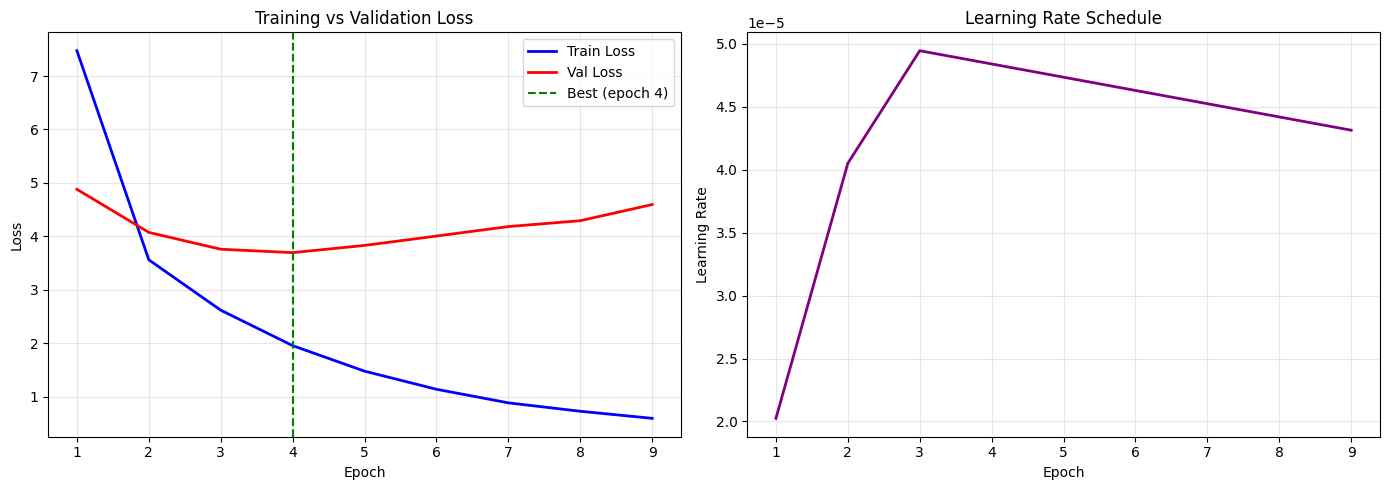

Plot saved to /content/drive/MyDrive/Chopin_waltz_completion/Models/fine_tuned/training_curves.png


In [15]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs = range(1, len(history["train_loss"]) + 1)

# Loss curves
ax1.plot(epochs, history["train_loss"], "b-", label="Train Loss", linewidth=2)
ax1.plot(epochs, history["val_loss"], "r-", label="Val Loss", linewidth=2)
best_epoch = history["val_loss"].index(min(history["val_loss"])) + 1
ax1.axvline(x=best_epoch, color="green", linestyle="--", label=f"Best (epoch {best_epoch})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Learning rate
ax2.plot(epochs, history["lr"], "purple", linewidth=2)
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Learning Rate")
ax2.set_title("Learning Rate Schedule")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"Plot saved to {OUTPUT_DIR / 'training_curves.png'}")